# TESI DI LAUREA 
## Cavallari Anna

## EDA & Preprocessing 

Questo notebook illustra un flusso completo di **Exploratory Data Analysis (EDA)** e **preprocessing** sul dataset COMPAS.

### Struttura del notebook
1. set up e caricamento iniziare dei dati
2. prima esplorazione dei dataset
3. controllo duplicati
4. selezione variabili utili
5. gestione valori mancanti
6. filtro ProPubblica
EDA
7. Analisi esplorativa variabili numeriche
    7.1 boxplot outlier
8. Analisi esplorativa variabili categoriche
9. Ricerca categorie rare
10. rilevamento outlier
11. Analisi delle correlazioni
12. EDA per variabile target
13. relazione variabile target e altre variabili
    13.1 categoriche
    13.2 numeriche
14. analisi variabile target e variabili sensibili race e sex
15. analisi score compas e gruppi sensibili race e sex
16. riassunto finale

## 1. Setup e caricamento iniziale dei dati

In [44]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


DOWNLOAD DATASET COMPAS

In [45]:
import os
import pandas as pd

file_path = "ds/compas-scores-two-years (1).csv"

df_raw = pd.read_csv(file_path)

print(f"Dataset caricato: {df_raw.shape[0]:,} righe × {df_raw.shape[1]} colonne")
df_raw.head()

Dataset caricato: 7,214 righe × 53 colonne


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


Subito dopo viene stampata la dimensione del dataset, cioè:

- numero di righe
- numero di colonne

e viene visualizzata un’anteprima delle prime osservazioni.

piccolo check

In [46]:
df_raw.shape
df_raw.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

- quante osservazioni sono presenti
- quali variabili sono disponibili

___
## 2. Prima esplorazione del dataset

In [47]:
df_raw.info()
df_raw.describe()


<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,7192.000,7214.000,2316.000,0.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000
mean,5501.256,34.818,0.067,4.510,0.091,0.109,3.472,3.305,57.731,0.481,20.269,NaN,0.114,4.510,3.692,3.472,11.465,553.437,0.383,0.451
std,3175.707,11.889,0.474,2.856,0.485,0.502,4.883,75.810,329.740,0.500,74.872,NaN,0.317,2.856,2.510,4.883,46.955,399.021,0.486,0.498
min,1.000,18.000,0.000,1.000,0.000,0.000,0.000,-414.000,0.000,0.000,-1.000,NaN,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,2735.250,25.000,0.000,2.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,NaN,0.000,2.000,1.000,0.000,0.000,148.250,0.000,0.000
50%,5509.500,31.000,0.000,4.000,0.000,0.000,2.000,-1.000,1.000,0.000,0.000,NaN,0.000,4.000,3.000,2.000,0.000,530.500,0.000,0.000
75%,8246.500,42.000,0.000,7.000,0.000,0.000,5.000,0.000,2.000,1.000,1.000,NaN,0.000,7.000,5.000,5.000,1.000,914.000,1.000,1.000
max,11001.000,96.000,20.000,10.000,13.000,17.000,38.000,1057.000,9485.000,1.000,993.000,NaN,1.000,10.000,10.000,38.000,937.000,1186.000,1.000,1.000


Con info() si osserva:

- se una colonna è numerica o categorica
- quante osservazioni non nulle ha
- se ci sono possibili problemi di formattazione

Con describe() si osservano per le variabili numeriche:

- media
- deviazione standard
- minimi e massimi
- quartili

In [48]:
df_raw.describe(include="all")


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214,7214,7214,7214,7214,7214,7214.000,7214,7214,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,6907,6907,7192,6055,1137,7192.000,7214,7185,7214.000,3471,3471,2316.000,3471,3413,2316,2316,0.000,7214.000,819,819,819,819,7214,7214.000,7214,7214,7214,7214.000,7214,7214,6978,6978,7214.000,7214.000,7214.000,7214.000,7214.000
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,6907,6880,7192,927,580,NaN,2,437,NaN,3471,10,NaN,1075,340,972,938,NaN,NaN,819,9,570,83,1,NaN,3,690,1,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,NaN,25 - 45,African-American,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,NaN,F,Battery,NaN,13009779CF10A,(M1),NaN,2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,NaN,NaN,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,NaN,Low,2013-02-20,Risk of Violence,NaN,Low,2013-02-20,2014-01-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,26,9,NaN,4666,1156,NaN,1,1201,NaN,12,258,9,9,NaN,NaN,1,344,6,329,7214,NaN,3897,32,7214,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.256,NaN,NaN,NaN,NaN,NaN,NaN,34.818,NaN,NaN,0.067,4.510,0.091,0.109,3.472,3.305,NaN,NaN,NaN,NaN,NaN,57.731,NaN,NaN,0.481,NaN,NaN,20.269,NaN,NaN,NaN,NaN,NaN,0.114,NaN,NaN,NaN,NaN,NaN,4.510,NaN,NaN,NaN,3.692,NaN,NaN,NaN,NaN,3.472,11.465,553.437,0.383,0.451
std,3175.707,NaN,NaN,NaN,NaN,NaN,NaN,11.889,NaN,NaN,0.474,2.856,0.485,0.502,4.883,75.810,NaN,NaN,NaN,NaN,NaN,329.740,NaN,NaN,0.500,NaN,NaN,74.872,NaN,NaN,NaN,NaN,NaN,0.317,NaN,NaN,NaN,NaN,NaN,2.856,NaN,NaN,NaN,2.510,NaN,NaN,NaN,NaN,4.883,46.955,399.021,0.486,0.498
min,1.000,NaN,NaN,NaN,NaN,NaN,NaN,18.000,NaN,NaN,0.000,1.000,0.000,0.000,0.000,-414.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000
25%,2735.250,NaN,NaN,NaN,NaN,NaN,NaN,25.000,NaN,NaN,0.000,2.000,0.000,0.000,0.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,148.250,0.000,0.000
50%,5509.500,NaN,NaN,NaN,NaN,NaN,NaN,31.000,NaN,NaN,0.000,4.000,0.000,0.000,2.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN,NaN,3.000,NaN,NaN,NaN,NaN,2.000,0.000,530.500,0.000,0.000
75%,8246.500,NaN,NaN,NaN,NaN,NaN,NaN,42.000,NaN,NaN,0.000,7.000,0.000,0.000,5.000,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,1.000,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,5.000,NaN,NaN,NaN,NaN,5.000,1.000,914.000,1.000,1.000


Con describe(include="all") si estende l’analisi anche alle categoriche:

- numero di valori osservati
- categoria più frequente
- frequenza della modalità

In [49]:
df_raw.isnull().sum().sort_values(ascending=False)


violent_recid              7214
vr_charge_degree           6395
vr_case_number             6395
vr_offense_date            6395
vr_charge_desc             6395
c_arrest_date              6077
r_jail_out                 4898
r_jail_in                  4898
r_days_from_arrest         4898
r_charge_desc              3801
r_offense_date             3743
r_case_number              3743
r_charge_degree            3743
c_offense_date             1159
c_jail_out                  307
days_b_screening_arrest     307
c_jail_in                   307
out_custody                 236
in_custody                  236
c_charge_desc                29
c_days_from_compas           22
c_case_number                22
v_type_of_assessment          0
type_of_assessment            0
decile_score.1                0
v_decile_score                0
v_score_text                  0
v_screening_date              0
screening_date                0
priors_count.1                0
start                         0
end     

Con isnull().sum() viene controllata la presenza di missing values in ciascuna colonna. in ordine ascendente ossia dal più alto al nullo

mostrare che ho analizzato la struttura del dataset prima della pulizia.

In [50]:
df_raw.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.000,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.000,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.000,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.000,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.000,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.000,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,brada

___
## 3. controllo duplicati

In [51]:
df_nodup = df_raw.drop_duplicates().copy()

before = len(df_raw)
after = len(df_nodup)

print(f"Duplicati rimossi: {before - after} righe")
print(f"Shape dopo rimozione duplicati: {df_nodup.shape}")


Duplicati rimossi: 0 righe
Shape dopo rimozione duplicati: (7214, 53)


Questo passaggio serve a evitare che eventuali osservazioni ripetute influenzino in modo scorretto l’analisi descrittiva e le analisi successive.
La rimozione dei duplicati migliora la qualità del dataset perché evita di sovrarappresentare alcuni casi.

___
## 4.selezioni varibili utili

In [52]:
cols = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "days_b_screening_arrest",
    "c_charge_degree",
    "is_recid",
    "score_text",
    "decile_score",
    "two_year_recid"
]

df_selected = df_nodup[cols].copy()

Qui si riduce il dataset alle sole variabili utili all’analisi della tesi, eliminando colonne non centrali rispetto al tema della recidiva e del bias algoritmico.

In [53]:
print("Shape dataset selezionato:", df_selected.shape)
print("\nColonne del dataset selezionato:")
display(pd.DataFrame({"colonne": df_selected.columns}))

Shape dataset selezionato: (7214, 11)

Colonne del dataset selezionato:


,colonne
0,age
1,age_cat
2,sex
3,race
4,priors_count
5,days_b_screening_arrest
6,c_charge_degree
7,is_recid
8,score_text
9,decile_score


Serve a confermare che:

- la riduzione delle variabili sia avvenuta correttamente
- il dataset finale per l’analisi contenga solo gli attributi scelti

___
## 5. gestione valori mancanti

In [54]:
missing_selected = pd.DataFrame({
    "count": df_selected.isnull().sum(),
    "percent": df_selected.isnull().mean() * 100
}).query("count > 0").sort_values("percent", ascending=False)

missing_selected

,count,percent
days_b_screening_arrest,307,4.256


Questo passaggio serve a valutare se nelle variabili selezionate siano presenti problemi di completezza che potrebbero alterare l’analisi.

In altre parole, è una verifica della qualità dei dati limitata al sottoinsieme effettivamente usato nella tesi.

____
## 6. Filtro ProPubblica

In [55]:
df_filtered = df_selected[
    (df_selected["days_b_screening_arrest"] <= 30) &
    (df_selected["days_b_screening_arrest"] >= -30) &
    (df_selected["is_recid"] != -1) &
    (df_selected["c_charge_degree"] != "O") &
    (df_selected["score_text"] != "N/A")
].copy()

print("Shape dopo filtro ProPublica:", df_filtered.shape)

Shape dopo filtro ProPublica: (6172, 11)


Il dataset viene filtrato secondo i criteri usati da ProPublica nel famoso lavoro di analisi del caso COMPAS. In particolare vengono mantenute solo le osservazioni che rispettano queste condizioni:

a) days_b_screening_arrest compreso tra -30 e +30

Vengono esclusi i casi in cui la differenza tra screening e arresto è troppo ampia.

b) is_recid != -1

Si eliminano i casi con codifica anomala o non interpretabile rispetto alla recidiva.

c) c_charge_degree != "O"

Si escludono le osservazioni con una tipologia di accusa non rilevante o non coerente con l’analisi standard.

d) score_text != "N/A"

Si eliminano i casi in cui il sistema non ha assegnato una classificazione interpretabile del rischio.

In [56]:
df_filtered.isnull().sum()

age                        0
age_cat                    0
sex                        0
race                       0
priors_count               0
days_b_screening_arrest    0
c_charge_degree            0
is_recid                   0
score_text                 0
decile_score               0
two_year_recid             0
dtype: int64

In [57]:
df_filtered.shape

(6172, 11)

controllo ulteriore di eventuali valori residui

# EDA

___
## 7. Analisi esplorativa variabili numeriche

In [58]:
num_cols_main = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
bin_cols = ['is_recid', 'two_year_recid']

print('=== VARIABILI NUMERICHE PRINCIPALI ===')
display(
    df_filtered[num_cols_main].describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .highlight_min('mean', color='lightcoral')
)

print('=== VARIABILI BINARIE ===')
display(
    df_filtered[bin_cols].describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .highlight_min('mean', color='lightcoral')
)

=== VARIABILI NUMERICHE PRINCIPALI ===


,count,mean,std,min,25%,50%,75%,max
age,6172.000000,34.534511,11.730938,18.000000,25.000000,31.000000,42.000000,96.000000
priors_count,6172.000000,3.246436,4.743770,0.000000,0.000000,1.000000,4.000000,38.000000
days_b_screening_arrest,6172.000000,-1.740279,5.084709,-30.000000,-1.000000,-1.000000,-1.000000,30.000000
decile_score,6172.000000,4.418503,2.839463,1.000000,2.000000,4.000000,7.000000,10.000000


=== VARIABILI BINARIE ===


,count,mean,std,min,25%,50%,75%,max
is_recid,6172.000000,0.484446,0.499799,0.000000,0.000000,0.000000,1.000000,1.000000
two_year_recid,6172.000000,0.455120,0.498022,0.000000,0.000000,0.000000,1.000000,1.000000


Per ciascuna variabile numerica si osservano:

- conteggio
- media
- deviazione standard
- minimo
- quartili
- massimo

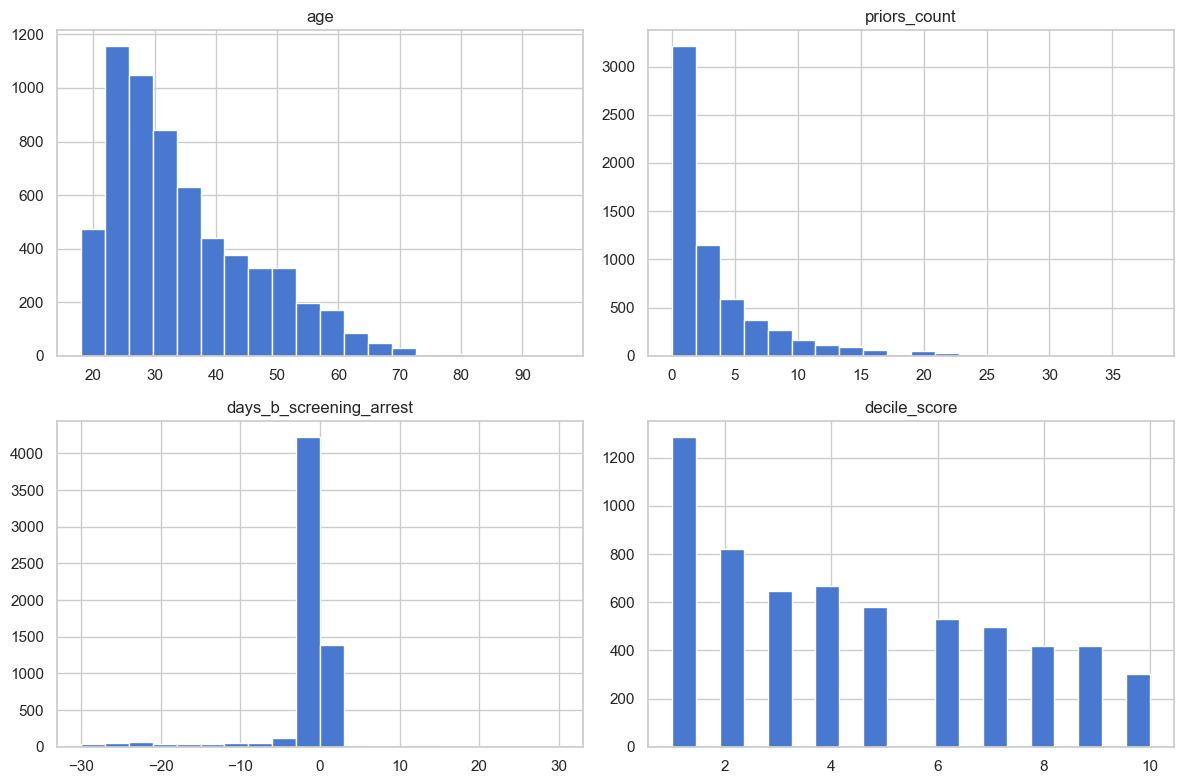

In [59]:
num_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

df_filtered[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

### 7.1 Boxplot outlier

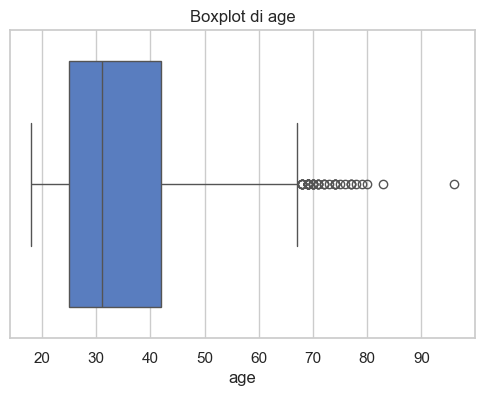

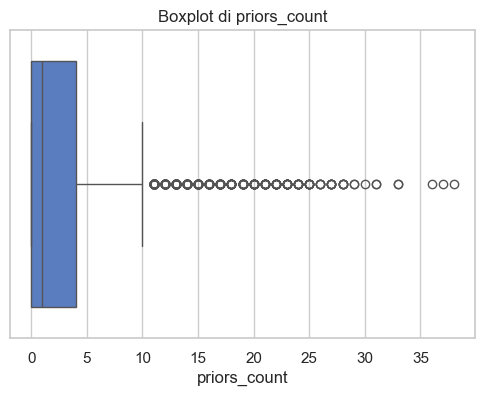

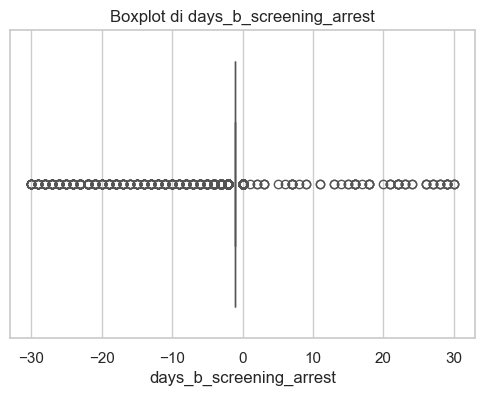

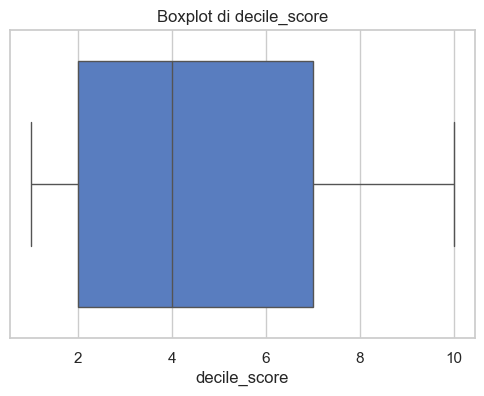

In [60]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_filtered[col])
    plt.title(f"Boxplot di {col}")
    plt.show()

___
## 8. Analisi esplorativa variabili categoriche

In [61]:
print('=== CATEGORICHE ===')
df_filtered.describe(include=['object', 'string'])

=== CATEGORICHE ===


,age_cat,sex,race,c_charge_degree,score_text
count,6172,6172,6172,6172,6172
unique,3,2,6,2,3
top,25 - 45,Male,African-American,F,Low
freq,3532,4997,3175,3970,3421


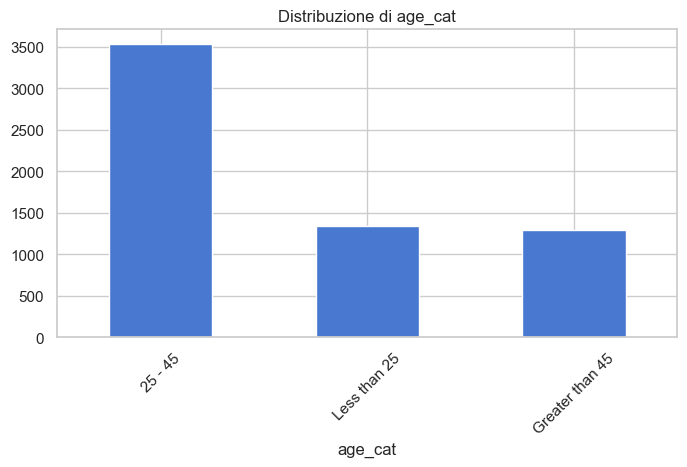

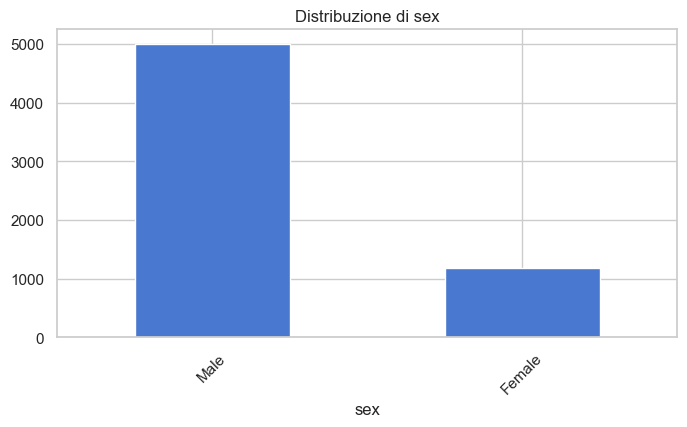

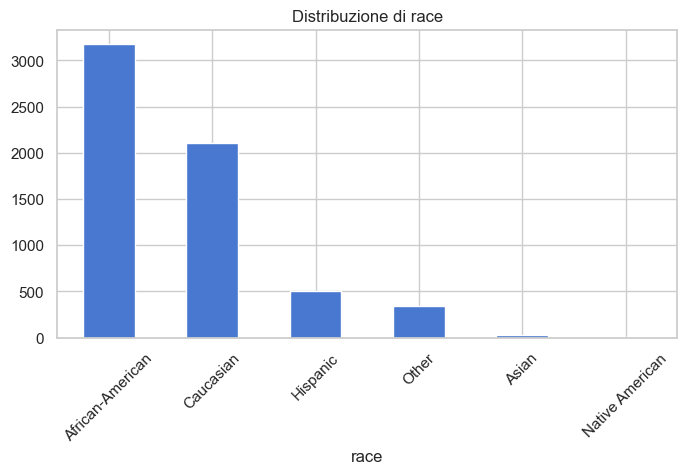

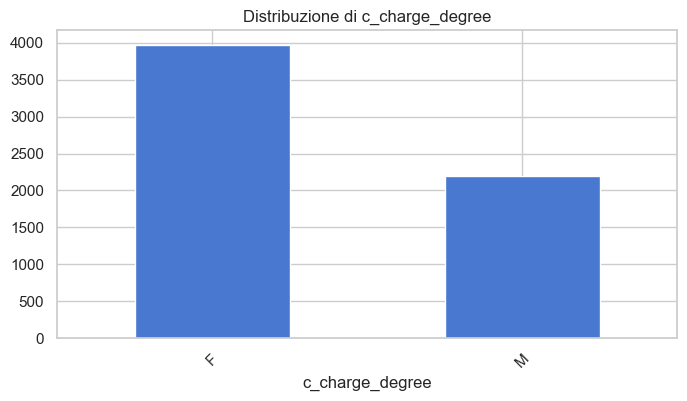

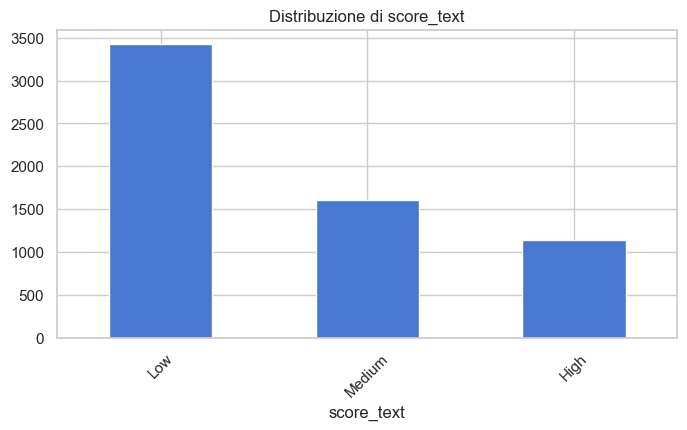

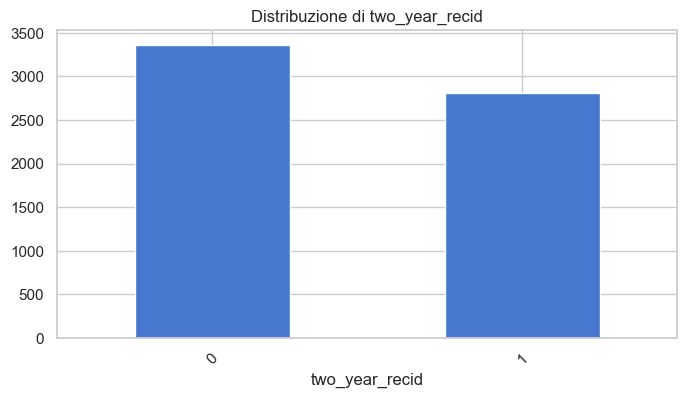

In [62]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text", "two_year_recid"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df_filtered[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribuzione di {col}")
    plt.xticks(rotation=45)
    plt.show()

In [63]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]

for col in cat_cols:
    print(f"\n===== {col} =====")
    print("Frequenze assolute:")
    print(df_filtered[col].value_counts(dropna=False))
    print("\nFrequenze percentuali:")
    print(round(df_filtered[col].value_counts(normalize=True, dropna=False) * 100, 2))


===== age_cat =====
Frequenze assolute:
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

Frequenze percentuali:
age_cat
25 - 45           57.230
Less than 25      21.820
Greater than 45   20.950
Name: proportion, dtype: float64

===== sex =====
Frequenze assolute:
sex
Male      4997
Female    1175
Name: count, dtype: int64

Frequenze percentuali:
sex
Male     80.960
Female   19.040
Name: proportion, dtype: float64

===== race =====
Frequenze assolute:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Frequenze percentuali:
race
African-American   51.440
Caucasian          34.070
Hispanic            8.250
Other               5.560
Asian               0.500
Native American     0.180
Name: proportion, dtype: float64

===== c_charge_degree =====
Frequenze assolute:
c_charge_degree
F    3970
M    2202
N

controllo cardinalità

In [64]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df_filtered[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
race,6
age_cat,3
score_text,3
sex,2
c_charge_degree,2


- quante modalità distinte ha ogni variabile
- se vi sono colonne con cardinalità eccessiva
- se alcune variabili richiederebbero una ricodifica

___
## 9. Ricerca delle categorie rare

In [65]:
threshold = 0.01

for col in cat_cols:
    freq = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_categories = freq[freq < threshold]

    print(f"\nCategorie rare in {col} (meno dell'1%):")
    print(rare_categories if not rare_categories.empty else "Nessuna categoria rara")


Categorie rare in age_cat (meno dell'1%):
Nessuna categoria rara

Categorie rare in sex (meno dell'1%):
Nessuna categoria rara

Categorie rare in race (meno dell'1%):
race
Asian             0.005
Native American   0.002
Name: proportion, dtype: float64

Categorie rare in c_charge_degree (meno dell'1%):
Nessuna categoria rara

Categorie rare in score_text (meno dell'1%):
Nessuna categoria rara


Viene impostata una soglia del 1% e per ogni colonna categorica vengono individuate le categorie con frequenza inferiore a quella soglia.

In [66]:
threshold = 0.01

for col in cat_cols:
    freq_rel = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_labels = freq_rel[freq_rel < threshold].index

    freq_abs = df_filtered[col].value_counts(dropna=False)
    rare_counts = freq_abs.loc[rare_labels]

    print(f"\nCategorie rare in {col} (meno dell'1%):")
    print(rare_counts if not rare_counts.empty else "Nessuna categoria rara")


Categorie rare in age_cat (meno dell'1%):
Nessuna categoria rara

Categorie rare in sex (meno dell'1%):
Nessuna categoria rara

Categorie rare in race (meno dell'1%):
race
Asian              31
Native American    11
Name: count, dtype: int64

Categorie rare in c_charge_degree (meno dell'1%):
Nessuna categoria rara

Categorie rare in score_text (meno dell'1%):
Nessuna categoria rara


In [67]:
df_filtered.shape

(6172, 11)

___
## 10. Rilevamente outlier

In [68]:
def detect_outliers_iqr(df, cols, k=1.5):
   
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'colonna': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'n_outliers': n_out,
            'pct_outliers': n_out / len(df) * 100
        })
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = detect_outliers_iqr(df_filtered, num_cols)
display(outlier_report.style.bar(subset=['pct_outliers'], color='#f4a261').format({'pct_outliers': '{:.2f}%'}))

,colonna,lower_bound,upper_bound,n_outliers,pct_outliers
2,days_b_screening_arrest,-1.000000,-1.000000,2192,35.52%
1,priors_count,-6.000000,10.000000,492,7.97%
0,age,-0.500000,67.500000,51,0.83%
3,decile_score,-5.500000,14.500000,0,0.00%


Per ogni variabile numerica la funzione stabilisce quali valori si trovano fuori dall’intervallo

Gli outlier vengono rilevati ma non rimossi automaticamente, poiché nel contesto giudiziario valori estremi possono rappresentare casi reali e informativamente rilevanti. La loro presenza viene quindi documentata e discussa, senza alterare il dataset finale destinato alle analisi successive.

___
## 11. Analisi delle correlazioni

In [69]:
corr_cols = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "two_year_recid"
]

corr_matrix = df_filtered[corr_cols].corr(method="spearman")

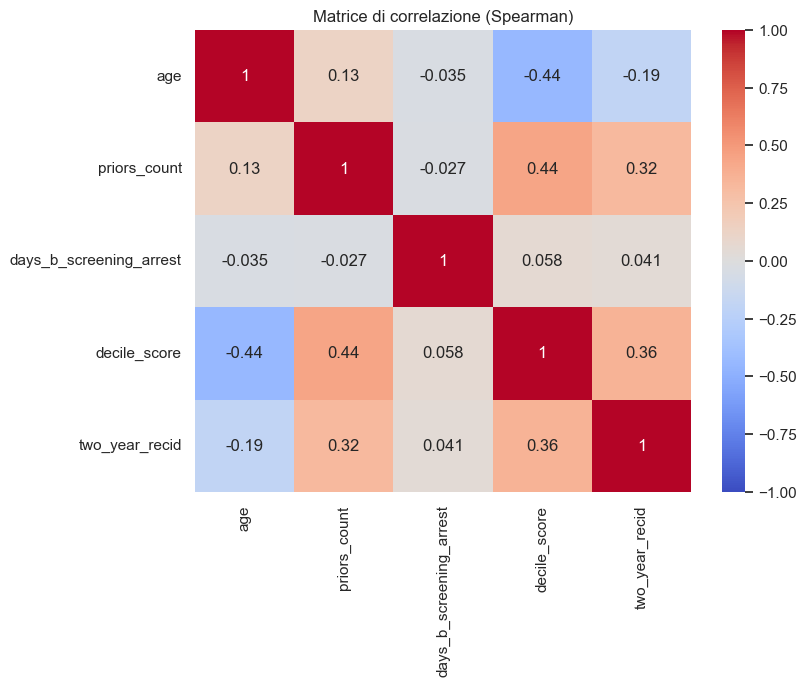

In [70]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Matrice di correlazione (Spearman)")
plt.show()

In [71]:
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlazione"]
corr_pairs["abs_corr"] = corr_pairs["correlazione"].abs()

corr_pairs.sort_values("abs_corr", ascending=False).head(10)

,feature_1,feature_2,correlazione,abs_corr
15,decile_score,age,-0.442,0.442
16,decile_score,priors_count,0.440,0.440
23,two_year_recid,decile_score,0.365,0.365
21,two_year_recid,priors_count,0.321,0.321
20,two_year_recid,age,-0.190,0.190
5,priors_count,age,0.128,0.128
17,decile_score,days_b_screening_arrest,0.058,0.058
22,two_year_recid,days_b_screening_arrest,0.041,0.041
10,days_b_screening_arrest,age,-0.035,0.035
11,days_b_screening_arrest,priors_count,-0.027,0.027


___
## 12. EDA per la varibile target

,two_year_recid,count,percent
0,0,3363,54.490
1,1,2809,45.510


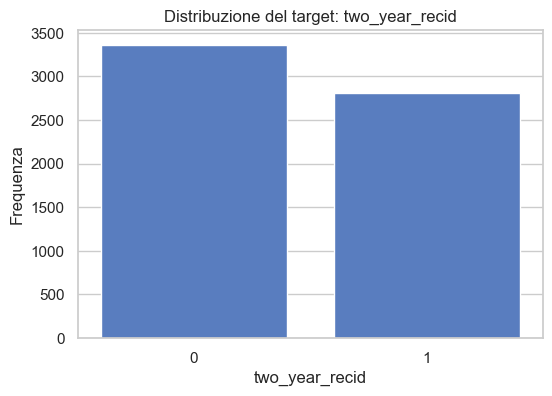

In [72]:
target_dist = (
    df_filtered["two_year_recid"]
    .value_counts(dropna=False)
    .rename_axis("two_year_recid")
    .reset_index(name="count")
)
target_dist["percent"] = (target_dist["count"] / len(df_filtered) * 100).round(2)

display(target_dist)

plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered, x="two_year_recid")
plt.title("Distribuzione del target: two_year_recid")
plt.xlabel("two_year_recid")
plt.ylabel("Frequenza")
plt.show()

___
## 13. Relazione variabile target e altre varibili

### 13.1 categoriche

Cosa mostra

Questa sezione consente di vedere come varia la quota di recidiva a seconda della categoria considerata.

two_year_recid,0,1
race,,
African-American,47.690,52.310
Asian,74.190,25.810
Caucasian,60.910,39.090
Hispanic,62.870,37.130
Native American,54.550,45.450
Other,63.850,36.150


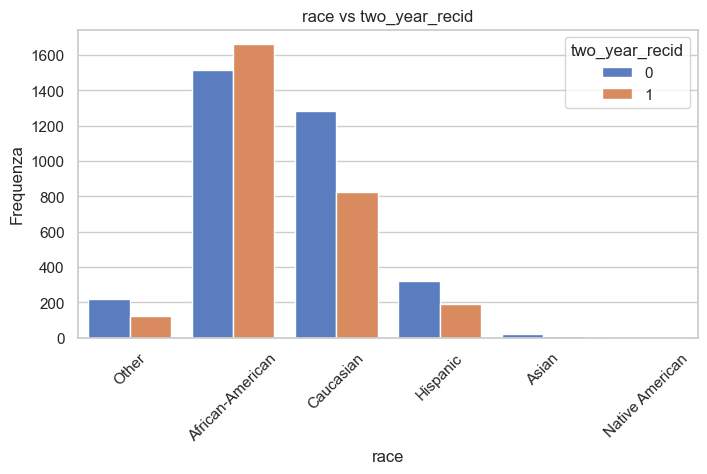

two_year_recid,0,1
sex,,
Female,64.850,35.150
Male,52.050,47.950


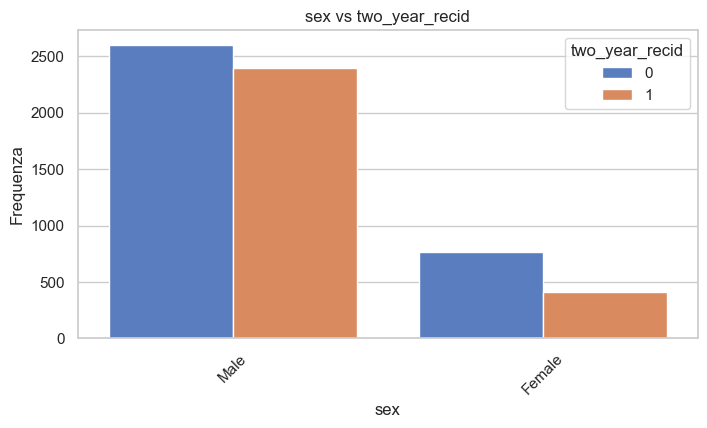

two_year_recid,0,1
age_cat,,
25 - 45,53.540,46.460
Greater than 45,67.980,32.020
Less than 25,44.020,55.980


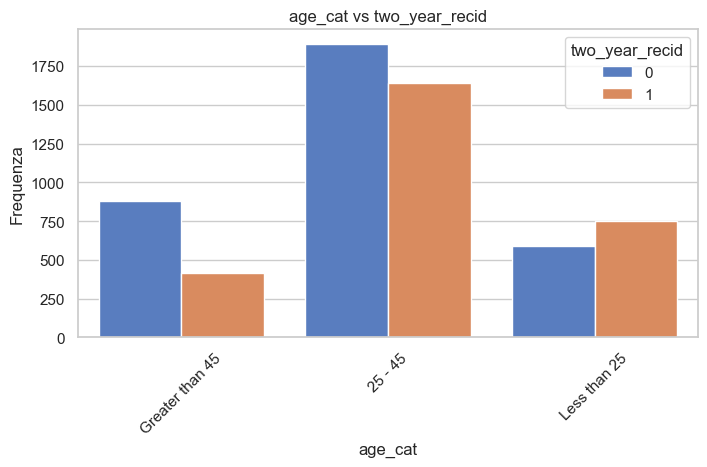

two_year_recid,0,1
c_charge_degree,,
F,50.030,49.970
M,62.530,37.470


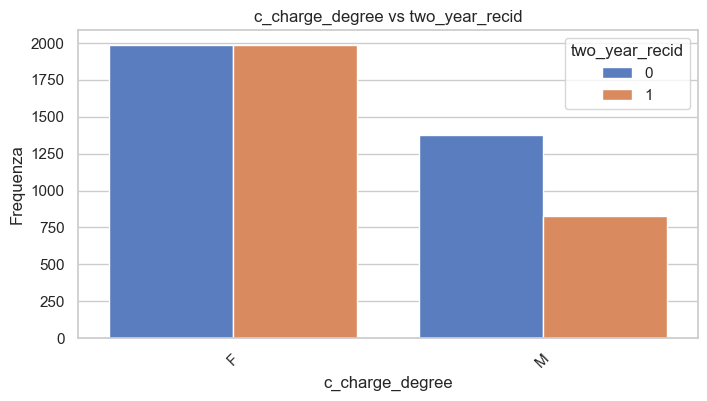

two_year_recid,0,1
score_text,,
High,25.960,74.040
Low,68.550,31.450
Medium,44.870,55.130


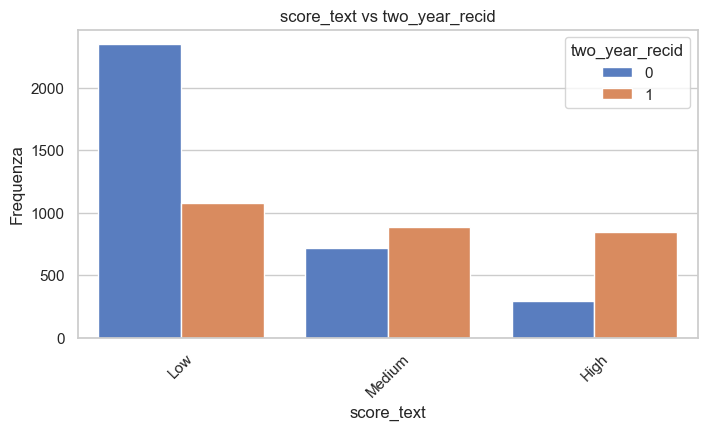

In [73]:
eda_cat_cols = ["race", "sex", "age_cat", "c_charge_degree", "score_text"]

for col in eda_cat_cols:
    summary = pd.crosstab(df_filtered[col], df_filtered["two_year_recid"], normalize="index") * 100
    display(summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=col, hue="two_year_recid")
    plt.title(f"{col} vs two_year_recid")
    plt.xticks(rotation=45)
    plt.ylabel("Frequenza")
    plt.show()

### 13.2 numeriche

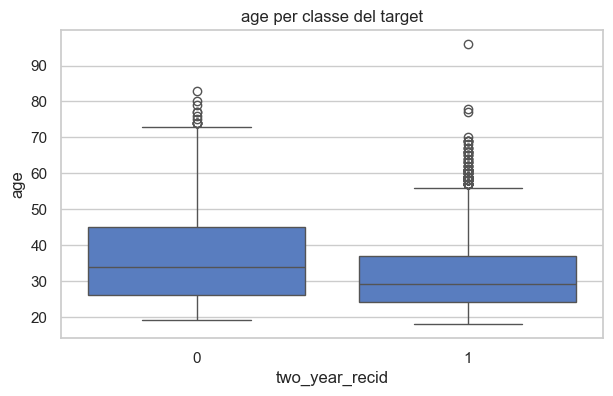

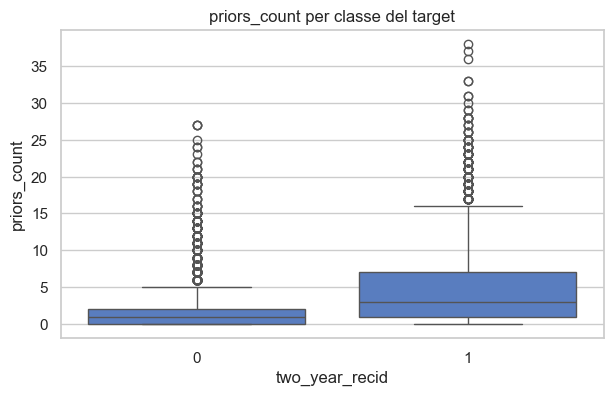

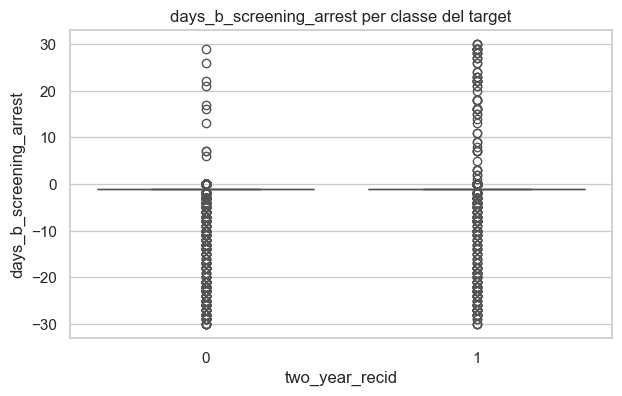

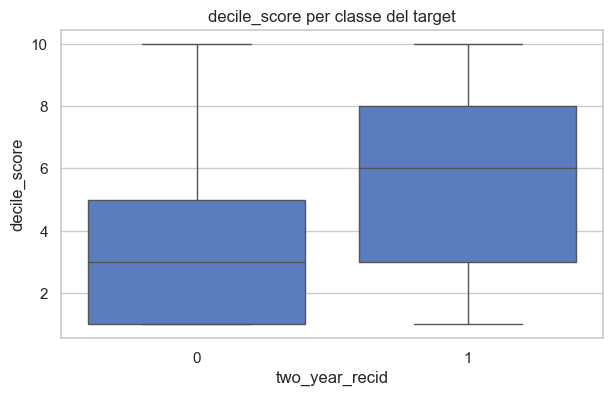

In [74]:
num_target_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

for col in num_target_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_filtered, x="two_year_recid", y=col)
    plt.title(f"{col} per classe del target")
    plt.show()


___
## 14. analisi variabile target e variabili sensibili race e sex


=== Distribuzione di race ===


,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11



Percentuali di two_year_recid per race:


two_year_recid,0,1
race,,
African-American,47.690,52.310
Asian,74.190,25.810
Caucasian,60.910,39.090
Hispanic,62.870,37.130
Native American,54.550,45.450
Other,63.850,36.150


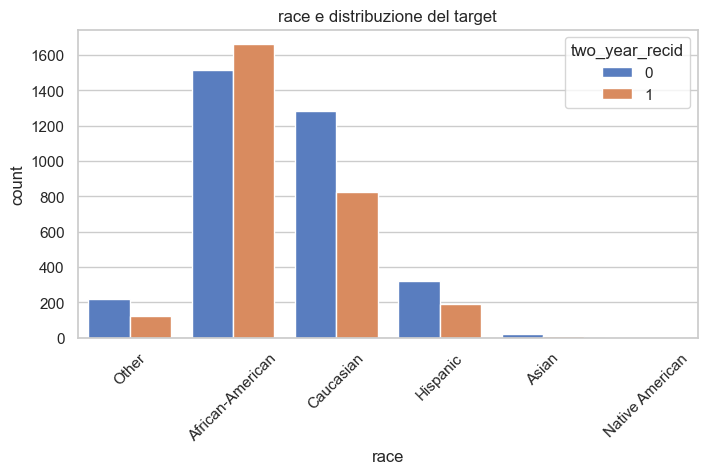


=== Distribuzione di sex ===


,count
sex,
Male,4997
Female,1175



Percentuali di two_year_recid per sex:


two_year_recid,0,1
sex,,
Female,64.850,35.150
Male,52.050,47.950


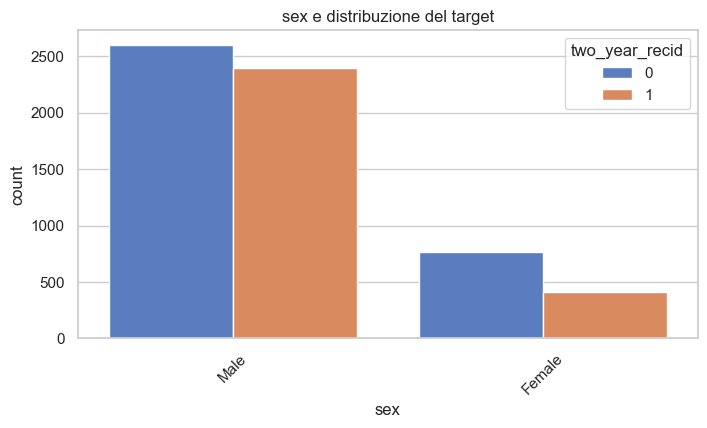

In [75]:
for sensitive_col in ["race", "sex"]:
    print(f"\n=== Distribuzione di {sensitive_col} ===")
    display(df_filtered[sensitive_col].value_counts(dropna=False).to_frame("count"))

    recid_by_group = pd.crosstab(
        df_filtered[sensitive_col],
        df_filtered["two_year_recid"],
        normalize="index"
    ) * 100
    print(f"\nPercentuali di two_year_recid per {sensitive_col}:")
    display(recid_by_group.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=sensitive_col, hue="two_year_recid")
    plt.title(f"{sensitive_col} e distribuzione del target")
    plt.xticks(rotation=45)
    plt.show()

___
## 15. analisi score compas e gruppi sensibili race e sex 


Distribuzione percentuale di score_text per race:


score_text,High,Low,Medium
race,,,
African-American,26.610,42.390,30.990
Asian,9.680,77.420,12.900
Caucasian,10.600,66.900,22.490
Hispanic,9.230,72.300,18.470
Native American,36.360,27.270,36.360
Other,6.410,79.590,13.990


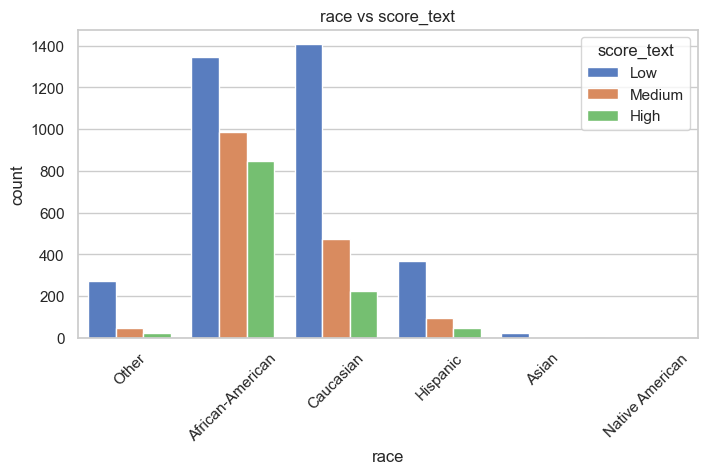


Distribuzione percentuale di score_text per sex:


score_text,High,Low,Medium
sex,,,
Female,12.850,59.490,27.660
Male,19.870,54.470,25.660


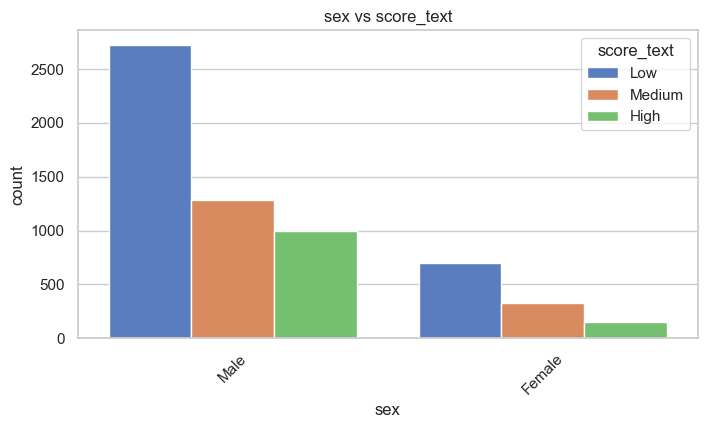

In [76]:
for sensitive_col in ["race", "sex"]:
    score_summary = pd.crosstab(
        df_filtered[sensitive_col],
        df_filtered["score_text"],
        normalize="index"
    ) * 100

    print(f"\nDistribuzione percentuale di score_text per {sensitive_col}:")
    display(score_summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=sensitive_col, hue="score_text")
    plt.title(f"{sensitive_col} vs score_text")
    plt.xticks(rotation=45)
    plt.show()

___
## 16. eliminazione categorie rare

In [77]:
df_final = df_filtered.copy()

threshold = 0.01  # soglia dell'1%

race_freq = df_final["race"].value_counts(normalize=True)
rare_races = race_freq[race_freq < threshold].index

print("Categorie rare da eliminare:")
print(list(rare_races))

df_final = df_final[~df_final["race"].isin(rare_races)].copy()

print("Shape prima dell'eliminazione:", df_filtered.shape)
print("Shape dopo l'eliminazione:", df_final.shape)

print("\nDistribuzione finale di race:")
print(df_final["race"].value_counts())

print("\nPercentuali finali:")
print(round(df_final["race"].value_counts(normalize=True) * 100, 2))

Categorie rare da eliminare:
['Asian', 'Native American']
Shape prima dell'eliminazione: (6172, 11)
Shape dopo l'eliminazione: (6130, 11)

Distribuzione finale di race:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Name: count, dtype: int64

Percentuali finali:
race
African-American   51.790
Caucasian          34.310
Hispanic            8.300
Other               5.600
Name: proportion, dtype: float64


___
## 17. riassunto finale

In [78]:
df_nodup = df_raw.drop_duplicates()
df_selected = df_nodup[cols].copy()

shape_summary = pd.DataFrame({
    "fase": [
        "Dataset originale",
        "Dopo rimozione duplicati",
        "Dopo selezione variabili",
        "Dopo filtro ProPublica", 
        "Dopo filtro categorie rare dataset finale"
    ],
    "n_righe": [
        df_raw.shape[0],
        df_nodup.shape[0],
        df_selected.shape[0],
        df_filtered.shape[0],
        df_final.shape[0]
    ],
    "n_colonne": [
        df_raw.shape[1],
        df_nodup.shape[1],
        df_selected.shape[1],
        df_filtered.shape[1],
        df_final.shape[1]
    ]
})

display(shape_summary)

,fase,n_righe,n_colonne
0,Dataset originale,7214,53
1,Dopo rimozione duplicati,7214,53
2,Dopo selezione variabili,7214,11
3,Dopo filtro ProPublica,6172,11
4,Dopo filtro categorie rare dataset finale,6130,11


In [79]:
# Esportazione dataset finale per Orange
output_path = "compas_clean_for_orange.csv"

df_final.to_csv(output_path, index=False)

print(f"Dataset esportato correttamente in: {output_path}")
print(f"Shape finale: {df_final.shape}")
df_final.head()

Dataset esportato correttamente in: compas_clean_for_orange.csv
Shape finale: (6130, 11)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,is_recid,score_text,decile_score,two_year_recid
0,69,Greater than 45,Male,Other,0,-1.000,F,0,Low,1,0
1,34,25 - 45,Male,African-American,0,-1.000,F,1,Low,3,1
2,24,Less than 25,Male,African-American,4,-1.000,F,1,Low,4,1
5,44,25 - 45,Male,Other,0,0.000,M,0,Low,1,0
6,41,25 - 45,Male,Caucasian,14,-1.000,F,1,Medium,6,1


___
# Preprocessing per la modellazione predittiva in Python


In questa fase il dataset viene preparato per l’addestramento dei modelli predittivi.  
Il preprocessing include:
-  la separazione tra variabili indipendenti e variabile target;
- la gestione delle variabili categoriche tramite codifica one-hot
- la suddivisione del dataset in training set e test set 
- la standardizzazione delle variabili numeriche.

La variabile target dell’analisi è `two_year_recid`, che indica se il soggetto ha recidivato entro due anni.

In [80]:
# Creazione di una copia del dataset finale
df_model = df_final.copy()

print("Shape dataset per la modellazione:", df_model.shape)
df_model.head()

Shape dataset per la modellazione: (6130, 11)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,is_recid,score_text,decile_score,two_year_recid
0,69,Greater than 45,Male,Other,0,-1.000,F,0,Low,1,0
1,34,25 - 45,Male,African-American,0,-1.000,F,1,Low,3,1
2,24,Less than 25,Male,African-American,4,-1.000,F,1,Low,4,1
5,44,25 - 45,Male,Other,0,0.000,M,0,Low,1,0
6,41,25 - 45,Male,Caucasian,14,-1.000,F,1,Medium,6,1


___
## 18 Separazione tra variabili indipendenti e variabile target

La variabile target è `two_year_recid`.  
Le altre variabili vengono considerate come predittori, ad eccezione di `is_recid`, che viene esclusa perché rappresenta un’informazione molto vicina alla recidiva osservata e potrebbe introdurre leakage informativo.

In [81]:
# Separazione tra variabili indipendenti X e target y

target = "two_year_recid"

features_to_drop = [
    target,
    "is_recid"
]

X = df_model.drop(columns=features_to_drop)
y = df_model[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.value_counts(normalize=True).round(3))

Shape X: (6130, 9)
Shape y: (6130,)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,score_text,decile_score
0,69,Greater than 45,Male,Other,0,-1.000,F,Low,1
1,34,25 - 45,Male,African-American,0,-1.000,F,Low,3
2,24,Less than 25,Male,African-American,4,-1.000,F,Low,4
5,44,25 - 45,Male,Other,0,0.000,M,Low,1
6,41,25 - 45,Male,Caucasian,14,-1.000,F,Medium,6


two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

In [82]:
print("Numero colonne in df_model:", df_model.shape[1])
print("Colonne df_model:")
print(df_model.columns.tolist())

print("\nNumero colonne in X:", X.shape[1])
print("Colonne X:")
print(X.columns.tolist())

Numero colonne in df_model: 11
Colonne df_model:
['age', 'age_cat', 'sex', 'race', 'priors_count', 'days_b_screening_arrest', 'c_charge_degree', 'is_recid', 'score_text', 'decile_score', 'two_year_recid']

Numero colonne in X: 9
Colonne X:
['age', 'age_cat', 'sex', 'race', 'priors_count', 'days_b_screening_arrest', 'c_charge_degree', 'score_text', 'decile_score']


___
## 19 identifico variabili 

In [83]:
# Identificazione delle variabili numeriche e categoriche

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("Variabili numeriche:")
print(numeric_features)

print("\nVariabili categoriche:")
print(categorical_features)

Variabili numeriche:
['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']

Variabili categoriche:
['age_cat', 'sex', 'race', 'c_charge_degree', 'score_text']


___ 
## 20. divisione train e test

In [85]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribuzione target nel training set:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuzione target nel test set:")
print(y_test.value_counts(normalize=True).round(3))

# Calcolo della divisione percentuale tra training set e test set

totale_osservazioni = len(X)

perc_train = (len(X_train) / totale_osservazioni) * 100
perc_test = (len(X_test) / totale_osservazioni) * 100

print("\nDivisione percentuale del dataset:")
print(f"Training set: {perc_train:.2f}%")
print(f"Test set: {perc_test:.2f}%")

X_train: (4291, 9)
X_test: (1839, 9)
y_train: (4291,)
y_test: (1839,)

Distribuzione target nel training set:
two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

Distribuzione target nel test set:
two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

Divisione percentuale del dataset:
Training set: 70.00%
Test set: 30.00%


___
## 21. Standardizzazione + One-Hot Encoding

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

StandardScaler → standardizza le variabili numeriche
OneHotEncoder → trasforma le variabili categoriche in variabili dummy
drop="first" → evita perfetta multicollinearità
handle_unknown="ignore" → evita errori se nel test set compare una categoria nuova

In [89]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Shape X_train preprocessato:", X_train_preprocessed.shape)
print("Shape X_test preprocessato:", X_test_preprocessed.shape)

Shape X_train preprocessato: (4291, 13)
Shape X_test preprocessato: (1839, 13)


recupero nomi delle nuove variabili create con OneHotEncoder

In [90]:
# Nomi delle feature numeriche
num_feature_names = numeric_features

# Nomi delle feature categoriche trasformate
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

# Nomi finali di tutte le feature
feature_names = list(num_feature_names) + list(cat_feature_names)

print("Numero totale di feature dopo preprocessing:", len(feature_names))
print(feature_names)

Numero totale di feature dopo preprocessing: 13
['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'age_cat_Greater than 45', 'age_cat_Less than 25', 'sex_Male', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'c_charge_degree_M', 'score_text_Low', 'score_text_Medium']


dataframe per leggere meglio

In [91]:
# Creazione dei DataFrame preprocessati

X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, "toarray") else X_train_preprocessed,
    columns=feature_names,
    index=X_train.index
)

X_test_preprocessed_df = pd.DataFrame(
    X_test_preprocessed.toarray() if hasattr(X_test_preprocessed, "toarray") else X_test_preprocessed,
    columns=feature_names,
    index=X_test.index
)

display(X_train_preprocessed_df.head())

,age,priors_count,days_b_screening_arrest,decile_score,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,race_Caucasian,race_Hispanic,race_Other,c_charge_degree_M,score_text_Low,score_text_Medium
4814,-0.385,-0.273,0.145,-1.211,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
6761,-0.213,0.144,0.145,1.976,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
5674,-0.642,-0.481,0.336,-0.503,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000
1696,2.017,-0.481,0.145,-1.211,1.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000
4278,-0.985,-0.690,0.145,-0.857,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000


Dopo l’applicazione della standardizzazione e del one-hot encoding, i dati trasformati vengono convertiti in DataFrame.  
Questa operazione non modifica il contenuto informativo del dataset, ma consente di mantenere una struttura tabellare leggibile e di associare ogni colonna trasformata al relativo nome della variabile.  

Il passaggio è utile soprattutto per l’interpretazione dei modelli, poiché permette di analizzare in modo più chiaro il ruolo delle variabili numeriche standardizzate e delle variabili dummy generate a partire dalle variabili categoriche.

piccolo check

In [92]:
print("Preprocessing completato correttamente.")

print("\nTraining set preprocessato:")
print(X_train_preprocessed_df.shape)

print("\nTest set preprocessato:")
print(X_test_preprocessed_df.shape)

print("\nTarget training:")
print(y_train.shape)

print("\nTarget test:")
print(y_test.shape)

print("\nValori mancanti nel training set preprocessato:")
print(X_train_preprocessed_df.isna().sum().sum())

print("\nValori mancanti nel test set preprocessato:")
print(X_test_preprocessed_df.isna().sum().sum())

Preprocessing completato correttamente.

Training set preprocessato:
(4291, 13)

Test set preprocessato:
(1839, 13)

Target training:
(4291,)

Target test:
(1839,)

Valori mancanti nel training set preprocessato:
0

Valori mancanti nel test set preprocessato:
0
